# SSD 实现


In [1]:
%matplotlib inline
import torch
import torchvision
from torch import nn
from torch.nn import functional as F
import util
import matplotlib.pyplot as plt

/root/autodl-tmp/envs/daily_learning/lib/python3.11/site-packages/requests/__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
img = plt.imread('./images/catdog.jpg')
h, w = img.shape[:2]
h, w

(561, 728)

## 多尺度锚框演示


在特征图（fmap）上生成锚框（anchors），每个像素作为锚框中心


In [3]:
def display_anchors(fmap_w, fmap_h, s, ratios=(1, 2, 0.5)):
    util.set_figsize()
    # 伪造一个特征图
    fmap = torch.zeros(1, 10, fmap_h, fmap_w)
    # 获取锚框
    anchors = util.multibox_prior(fmap, sizes=s, ratios=ratios)
    # 用于将锚框的相对坐标转换为图像的绝对坐标
    bbox_scale = torch.tensor((w, h, w, h))
    # imshow.axes 返回当前的坐标轴对象，anchors[0] 因为批量为 1，值域为 [0, 1]，所以需要乘以 bbox_scale
    util.show_bboxes(plt.imshow(img).axes, anchors[0] * bbox_scale)

探测小目标


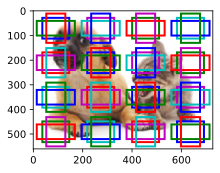

In [4]:
display_anchors(4, 4, s=[0.15])

特征图高宽减半，使用较大的锚框


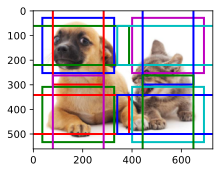

In [5]:
display_anchors(2, 2, s=[0.4])

最后缩成 1x1 的特征图


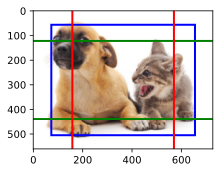

In [6]:
display_anchors(1, 1, s=[0.8])

## SSD 框架


### 预测分支
```mermaid
graph LR
    In(...) --> DS(下采样块)  --> F([特征图]) --> Out(...)
subgraph 预测分支
    CP(类别预测层) --> C([类别预测])
    BP(边界框预测层) --> B([边界框预测])
    A([锚框生成])  --> CP
    A --> BP
end
    F --> CP
    F --> BP
```

### 下采样阶段组成
```mermaid
graph LR
subgraph 预测分支
direction TB
    P1([预测])
    P2([预测])
    P3([预测])
    P4([预测])
    P5([预测])
end
    In([原始图像]) --> Ba(基本网络块) --> DS1(高宽减半块) --> DS2(高宽减半块) --> DS3(高宽减半块) --> GP(全局池化)
    Ba --> P1
    DS1 --> P2
    DS2 --> P3
    DS3 --> P4
    GP --> P5
```

## 预测层


### 类别预测层
这里面隐藏了一个操作。

- 卷积核的配置（k=3, p=1）保证了输出高宽不变
- 输入特征图 (cin, h, w) 输出 (cout, h, w)
- 输出通道 cout = num_anchors * (num_classes + 1)
  - num_anchors 是每个像素上生成的锚框数量
  - num_classes + 1 是每个锚框对每个类的概率，+1 是背景类
- 每个像素上都有 cout 个输出，表示特征图每个像素上生成的所有锚框的类别预测结果


In [7]:
def cls_predictor(num_inputs, num_anchors, num_classes):
    """从某一层的特征图预测每个锚框的类别"""
    return nn.Conv2d(num_inputs,
                     num_anchors * (num_classes + 1),
                     kernel_size=3, padding=1)

### 边界框预测层
同理得到每个像素上所有锚框的边界框偏移量预测结果，输出通道数为 num_anchors * 4
- num_anchors 是每个像素上生成的锚框数量
- 4 是每个锚框的偏移量 (dx, dy, dw, dh)


In [8]:
def bbox_predictor(num_inputs, num_anchors):
    """从某一层的特征图预测每个锚框的偏移量"""
    return nn.Conv2d(num_inputs, num_anchors * 4, kernel_size=3, padding=1)

### 多尺度预测


In [9]:
def forward(x, block):
    """前向计算"""
    return block(x)
# 8 通道 20x20 的特征图上每个像素生成 5 个锚框，预测 10 个类别
Y1 = forward(torch.zeros((2, 8, 20, 20)), cls_predictor(8, 5, 10))
# 每个像素上产生 5 x (10 + 1) = 55 个输出
print(Y1.shape)
# 16 通道 10x10 的特征图上每个像素生成 3 个锚框，预测 10 个类别
Y2 = forward(torch.zeros((2, 16, 10, 10)), cls_predictor(16, 3, 10))
# 每个像素上产生 3 x (10 + 1) = 33 个输出
print(Y2.shape)

torch.Size([2, 55, 20, 20])
torch.Size([2, 33, 10, 10])


In [10]:
def flatten_pred(pred):
    """将预测结果展平"""
    # (B, C, H, W) -> (B, H, W, C) -> (B, H * W * C)
    return torch.flatten(pred.permute(0, 2, 3, 1), start_dim=1)

def concat_preds(preds):
    """将多个预测结果展平后连接在一起"""
    return torch.cat([flatten_pred(p) for p in preds], dim=1)

# (2, 20, 20, 55) -> (2, 22000)
# (2, 10, 10, 33) -> (2, 3300)
# -> (2, 25300)
concat_preds([Y1, Y2]).shape

torch.Size([2, 25300])

## 网络块


### 高宽减半块
每个尺度之间的转换块（下采样）


In [11]:
def down_sample_blk(in_channels, out_channels):
    """高宽减半块，通道一般翻倍"""
    blk = []
    for _ in range(2):
        blk.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1))
        blk.append(nn.BatchNorm2d(out_channels))
        blk.append(nn.ReLU())
        in_channels = out_channels
    blk.append(nn.MaxPool2d(2)) # 默认 stride=2 所以高宽减半
    return nn.Sequential(*blk)

forward(torch.zeros((2, 3, 20, 20)), down_sample_blk(3, 6)).shape

torch.Size([2, 6, 10, 10])

### 基本网络块
从原始图像到第一次开始生成锚框的特征图之间的网络块

$(3, w, h) \rightarrow (64, \cfrac{w}{8}, \cfrac{h}{8})$


In [12]:
def base_net():
    """基本网络块"""
    blk = []
    num_filters = [3, 16, 32, 64]
    for i in range(len(num_filters) - 1):
        blk.append(down_sample_blk(num_filters[i], num_filters[i + 1]))
    return nn.Sequential(*blk)

## 完整网络


完整网络由 5 模块组成


In [13]:
def get_blk(i):
    """返回第 i 个块"""
    if i == 0: # 第 0 个块是基本网络块，从原始图到第一个特征图
        return base_net()
    elif i == 1: # 第一次高宽减半块，通道翻倍
        return down_sample_blk(64, 128)
    elif i == 4: # 最后是全局最大池化
        return nn.AdaptiveMaxPool2d((1, 1))
    else: # 其他都是高宽减半块，通道不变
        return down_sample_blk(128, 128)

定义每个块的前向计算
- 获得特征图
- 生成锚框
- 预测类别
- 预测偏移量


In [14]:
def stage_forward(X, blk, sizes, ratios, cls_predictor, bbox_predictor):
    """每个阶段的前向计算"""
    Y = blk(X) # 获得特征图
    anchors = util.multibox_prior(Y, sizes=sizes, ratios=ratios) # 生成锚框
    # SSD 锚框预测是直接看整图，逐像素产生结果，不用管锚框具体覆盖范围
    cls_preds = cls_predictor(Y) # 预测类别
    bbox_preds = bbox_predictor(Y) # 预测偏移量
    return (Y, anchors, cls_preds, bbox_preds)

## 超参数


In [15]:
# 锚框大小
sizes = [[0.2, 0.272],  # 32x32 特征图上
         [0.37, 0.447], # 16x16
         [0.54, 0.619], # 8x8
         [0.71, 0.79],  # 4x4
         [0.88, 0.961]] # 2x2

# 锚框高宽比
ratios = [[1, 2, 0.5]] * 5 # 每个尺度上都使用相同的高宽比

# 每个像素上生成的锚框数量
num_anchors = len(sizes[0]) + len(ratios[0]) - 1 # 之前的组合方式，n + m - 1 代替 n * m

## 完整 SSD 模型


In [16]:
class TinySSD(nn.Module):
    """简化版 SSD"""
    def __init__(self, num_classes, **kwargs):
        super(TinySSD, self).__init__(**kwargs)
        self.num_classes = num_classes
        # 每个块的输出通道数
        index_to_channel = [64, 128, 128, 128, 128]
        # 5 个块
        for i in range(5):
            # setattr 动态设置属性，可以 self.blk0 这样访问
            setattr(self, f'blk{i}', get_blk(i)) # 高宽减半块
            setattr(self, f'cls{i}', cls_predictor(index_to_channel[i], num_anchors, num_classes)) # 类别预测层
            setattr(self, f'bbox{i}', bbox_predictor(index_to_channel[i], num_anchors)) # 边界框预测层

    def forward(self, X):
        # 初始化 5 个 stage 的输出
        anchors, cls_preds, bbox_preds = [None] * 5, [None] * 5, [None] * 5
        for i in range(5):
            # 获取三个模块
            blk, cls, bbox = getattr(self, f'blk{i}'), getattr(self, f'cls{i}'), getattr(self, f'bbox{i}')
            # 前向计算
            X, anchors[i], cls_preds[i], bbox_preds[i] = stage_forward(X, blk, sizes[i], ratios[i], cls, bbox)
        # 将 5 个 stage 的输出连接在一起
        anchors = torch.cat(anchors, dim=1) # 连接所有锚框
        cls_preds = concat_preds(cls_preds)# 连接所有类别预测
        bbox_preds = concat_preds(bbox_preds) # 连接所有边界框预测
        # (B, H * W * anc * (cls + 1)) -> (B, H * W * anc, cls + 1) 方便对 cls 维度做 softmax
        cls_preds = cls_preds.reshape(cls_preds.shape[0], -1, self.num_classes + 1)
        return anchors, cls_preds, bbox_preds

## 使用实例


检查形状


In [17]:
net = TinySSD(num_classes=1) # 识别单一物品（香蕉）
X = torch.zeros((32, 3, 256, 256)) # 32 张 256x256 的 RGB 图像
anchors, cls_preds, bbox_preds = net(X)
print('输出锚框:', anchors.shape) # (B, H * W * anc, 4) 最后 4 是锚框位置 (x, y, w, h)
print('输出类别预测:', cls_preds.shape) # (B, H * W * anc, cls + 1)
print('输出边界框预测:', bbox_preds.shape) # (B, H * W * anc * 4) 最后 4 是边界框偏移量 (dx, dy, dw, dh)

输出锚框: torch.Size([1, 5444, 4])
输出类别预测: torch.Size([32, 5444, 2])
输出边界框预测: torch.Size([32, 21776])


### 数据集


In [18]:
batch_size = 32
train_iter, _ = util.data.load_data_bananas(batch_size)

read 1000 training examples
read 100 validation examples


### 损失函数


*补充知识点*
#### 范数 $||x||_p$ 或 $L_p(x)$

定义为向量中的各个元素的绝对值的 $p$ 次方之和的 $\cfrac{1}{p}$ 次方。
$$
L_p(x) = \left( \sum_i |x_i|^p \right)^{1/p}
$$

衡量向量的大小，也可以理解为向量到原点的距离

- **$L_1$ 范数**: 曼哈顿距离，向量各元素绝对值之和 $L_1(x) = \left( \sum_i |x_i|^1 \right)^{1} = \sum_i |x_i|$

- **$L_2$ 范数**: 欧几里得距离，向量各元素平方和的平方根 $L_2(x) = \left( \sum_i |x_i|^2 \right)^{1/2}$

- **$L_\infty$ 范数**: 切比雪夫距离，向量各元素绝对值的最大值 $L_\infty(x) = \left( \sum_i |x_i|^\infty \right)^{1/\infty} = \max_i |x_i|$

#### 损失函数
相应地，即衡量两向量差的大小，或者说两向量间的距离
- **$L_1$ 损失**: $L_1(y, \hat{y}) = \sum_i |y_i - \hat{y}_i|$

- **$L_2$ 损失**: $L_2(y, \hat{y}) = \sum_i (y_i - \hat{y}_i)^2$

衍生出更平滑的损失
- **平均绝对值误差**: $MAE(y, \hat{y}) = \cfrac{L_1(y, \hat{y})}{n}$
- **均方误差**: $MSE(y, \hat{y}) = \cfrac{L_2(y, \hat{y})}{n}$


In [19]:
cls_loss = nn.CrossEntropyLoss(reduction='none') # 类别预测损失是交叉熵
bbox_loss = nn.L1Loss(reduction='none') # 边界框预测损失是 L1 损失

def calc_loss(cls_preds, cls_labels, bbox_preds, bbox_labels, bbox_masks):
    """计算损失"""
    batch_size, num_classes = cls_preds.shape[0], cls_preds.shape[2]
    # 计算类别预测损失
    cls = (cls_loss(cls_preds.reshape(-1, num_classes), # 预测概率 (B * H * W * anc, cls + 1)
                    cls_labels.reshape(-1)). # 真实标签 (B * H * W * anc)
                    reshape(batch_size, -1). # 损失 (B, H * W * anc)
                    mean(dim=1)) # 对每个样本求平均 (B,)，因为所有像素的锚框共享分类层
    # 计算边界框预测损失
    bbox = (bbox_loss(bbox_preds * bbox_masks, # 预测偏移量用掩码忽略背景上的锚框 (B, H * W * anc, 4)
                      bbox_labels * bbox_masks). # 真实偏移量也忽略背景 (B, H * W * anc, 4)
                      mean(dim=1)) # 对每个样本求平均 (B, 4)，因为所有像素的锚框共享回归层
    # 返回总损失
    return cls + bbox # 也可以加权

def cls_eval(cls_preds, cls_labels):
    """计算分类准确率"""
    return float((cls_preds.argmax(dim=-1).type(cls_labels.dtype) == cls_labels).sum())

def bbox_eval(bbox_preds, bbox_labels, bbox_masks):
    """计算边界框预测的平均绝对误差"""
    return float((torch.abs((bbox_labels - bbox_preds) * bbox_masks)).sum())

### 初始化参数和优化


In [20]:
device = util.try_gpu()
net = TinySSD(num_classes=1).to(device)
def init_weights(m):
    if type(m) in [nn.Conv2d, nn.Linear]:
        nn.init.xavier_uniform_(m.weight)
net.apply(init_weights)
trainer = torch.optim.SGD(net.parameters(), lr=1e-2, weight_decay=5e-4)

### 训练


In [21]:
def train(net, num_epochs):
    timer = util.Timer()
    animator = util.Animator(xlabel='epoch', xlim=[1, num_epochs], legend=['class error', 'bbox mae'])
    for epoch in range(num_epochs):
        # 分类准确率、样本数、边界框平均绝对误差、有有效锚框数
        metric = util.Accumulator(4)
        net.train()
        for features, target in train_iter:
            timer.start()
            trainer.zero_grad()
            X, Y = features.to(device), target.to(device).type(torch.float32)
            # 前向计算
            anchors, cls_preds, bbox_preds = net(X)
            # 生成真实标签
            bbox_labels, bbox_masks, cls_labels = util.multibox_target(anchors, Y)
            # 计算损失并反向传播
            l = calc_loss(cls_preds, cls_labels, bbox_preds, bbox_labels, bbox_masks)
            l.mean().backward()
            trainer.step()
            with torch.no_grad():
                metric.add(cls_eval(cls_preds, cls_labels), # 分类准确率
                           cls_labels.numel(), # 样本数
                           bbox_eval(bbox_preds, bbox_labels, bbox_masks), # 边界框平均绝对误差
                           bbox_labels.numel()) # 有有效锚框数
        # 计算分类错误率和边界框平均绝对误差
        cls_err, bbox_mae = 1 - metric[0] / metric[1], metric[2] / metric[3]
        animator.add(epoch + 1, (cls_err, bbox_mae))
    print(f'分类错误率 {cls_err:.2e}, 边界框平均绝对误差 {bbox_mae:.2e}')
    print(f'{len(train_iter.dataset) / timer.stop():.1f} examples/sec on '
          f'{str(device)}')

分类错误率 5.42e-03, 边界框平均绝对误差 6.04e-03
16374.7 examples/sec on cuda:0


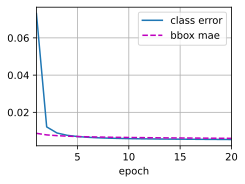

In [22]:
train(net, 20)

### 预测目标


In [23]:
def predict(X):
    """预测目标"""
    net.eval()
    anchors, cls_preds, bbox_preds = net(X.to(device))
    cls_probs = F.softmax(cls_preds, dim=-1).detach().permute(0, 2, 1) # 计算类别概率，转置为 (B, 类别, 锚框)
    output = util.multibox_detection(cls_probs, bbox_preds, anchors) # 预测边界框
    idx = [i for i, row in enumerate(output[0]) if row[0] != -1] # 过滤掉背景类
    return output[0, idx] # 返回预测结果

X = torchvision.io.read_image('./images/banana.jpg').unsqueeze(0).float() # 读取图像并增加批量维度
img = X.squeeze(0).permute(1, 2, 0).long() # 转换为 (H, W, C) 方便显示
output = predict(X)

显示


/tmp/ipykernel_159625/175557685.py:5: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:822.)
  score = float(row[1])


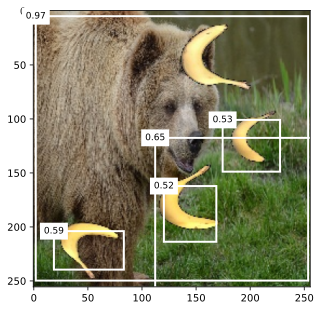

In [24]:
def display(img, output, threshold):
    util.set_figsize((5, 5))
    fig = plt.imshow(img) # 显示原图
    for row in output:
        score = float(row[1])
        if score < threshold: # 过滤掉低分数的预测结果
            continue
        h, w = img.shape[:2]
        bbox = [row[2:6] * torch.tensor((w, h, w, h), device=row.device).detach()]
        util.show_bboxes(fig.axes, bbox, '%.2f' % score, 'w')

display(img, output.cpu(), threshold=0.5)